# Análise de Comentários do YouTube

Este notebook analisa o dataframe `dfcomentarios`, com foco na **série temporal mensal de comentários publicados**.

Atributos esperados em `dfcomentarios`:
`video_id, comment_id, author, author_profile_image_url, author_channel_url, author_channel_id, comment, published_at, updated_at, like_count, viewer_rating, can_rate, is_reply, parent_id, channel_id`

Opcionalmente cruzamos com `dfvideos` e `dfcanais_unico`.

## 0. Setup

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 1. Preparação do ambiente

Montamos o Google Drive para acessar os arquivos do dataset.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Carregamento


Ajuste o caminho para o seu arquivo (`.csv` ou `.parquet`).

In [6]:
# importa o arquivo e guarda em um dataframe do Pandas
PATH1 = '../fastback/fastback/comments_info.csv'
PATH2 = '../fastback/fastback/videos_info.csv'
PATH3 = '../fastback/fastback/channels_info.csv'

#verifica se é csv ou parquet
def read_any(p):
    return pd.read_parquet(p) if str(p).endswith(".parquet") else pd.read_csv(p)

dfcomentarios = read_any(PATH1)
print(dfcomentarios.shape)
print('Dados importados com sucesso!')
dfcomentarios.head(20)


(42585, 15)
Dados importados com sucesso!


,video_id,comment_id,author,author_profile_image_url,author_channel_url,author_channel_id,comment,published_at,updated_at,like_count,viewer_rating,can_rate,is_reply,parent_id,channel_id
0,RyugQPweL8g,Ugyl5YswpiVf66UJULd4AaABAg,@barretoscars,https://yt3.ggpht.com/8WYHToJUjMK4W49S7omNMZA7...,http://www.youtube.com/@barretoscars,UCseokvqYrVPFv31rtGgJFEQ,Comenta aqui a sua cidade e seu estado 👇🏻👇🏻👇🏻,2026-05-06T05:40:29Z,2026-05-06T05:40:29Z,1,none,True,False,NaN,UCseokvqYrVPFv31rtGgJFEQ
1,GAqK5e2a5xY,Ugz4B9csFmGGfFpx_WV4AaABAg,@CovardeCovarde-u8k5n,https://yt3.ggpht.com/ytc/AIdro_nBDeZ9mqdIFB9Z...,http://www.youtube.com/@CovardeCovarde-u8k5n,UCwkzCUaX4pjLWIqWFJ7pkAQ,Esse torque. Essa aceleracao.\n9 por litros.\n...,2026-05-25T10:03:12Z,2026-05-25T10:03:12Z,0,none,True,False,NaN,UCT2J6PZM2W1Zl2kcBcFEe9A
2,GAqK5e2a5xY,Ugz4B9csFmGGfFpx_WV4AaABAg.AXDzwReBJ6UAXFH35X_jnk,@CanalGTAutos,https://yt3.ggpht.com/geA6paAb6xscxB8G-WjnEhui...,http://www.youtube.com/@CanalGTAutos,UCT2J6PZM2W1Zl2kcBcFEe9A,Pensei em colocar uma série de argumentos aqui...,2026-05-25T22:00:46Z,2026-05-25T22:00:46Z,0,none,True,True,Ugz4B9csFmGGfFpx_WV4AaABAg,UCT2J6PZM2W1Zl2kcBcFEe9A
3,GAqK5e2a5xY,Ugz4B9csFmGGfFpx_WV4AaABAg.AXDzwReBJ6UAXFHjDXl4DM,@CovardeCovarde-u8k5n,https://yt3.ggpht.com/ytc/AIdro_nBDeZ9mqdIFB9Z...,http://www.youtube.com/@CovardeCovarde-u8k5n,UCwkzCUaX4pjLWIqWFJ7pkAQ,​@CanalGTAutos😂😂😂😂😂😂.\nUma serie de argumento ...,2026-05-25T22:06:39Z,2026-05-25T22:06:39Z,0,none,True,True,Ugz4B9csFmGGfFpx_WV4AaABAg,UCT2J6PZM2W1Zl2kcBcFEe9A
4,GAqK5e2a5xY,Ugz4B9csFmGGfFpx_WV4AaABAg.AXDzwReBJ6UAXFI7tBnj_f,@CanalGTAutos,https://yt3.ggpht.com/geA6paAb6xscxB8G-WjnEhui...,http://www.youtube.com/@CanalGTAutos,UCT2J6PZM2W1Zl2kcBcFEe9A,​@CovardeCovarde-u8k5nQualquer coisa vai avisa...,2026-05-25T22:10:09Z,2026-05-25T22:10:09Z,0,none,True,True,Ugz4B9csFmGGfFpx_WV4AaABAg,UCT2J6PZM2W1Zl2kcBcFEe9A
5,GAqK5e2a5xY,UgwLglOkM87vZ04Ktm54AaABAg,@jager-6968,https://yt3.ggpht.com/ytc/AIdro_krAfUF8DWQtSqX...,http://www.youtube.com/@jager-6968,UC5cp2ubWEVWhgs-mRoz35mQ,SUV ?,2026-05-20T01:54:13Z,2026-05-20T01:54:13Z,0,none,True,False,NaN,UCT2J6PZM2W1Zl2kcBcFEe9A
6,GAqK5e2a5xY,UgywWYeqpisG-XXob5t4AaABAg,@flyadesivos,https://yt3.ggpht.com/ytc/AIdro_mZdHSY3ztS9BO9...,http://www.youtube.com/@flyadesivos,UCFFjF5WhulhwtvZq4tiDqmA,Tá fazendo mais que meu tera 1.0tsi,2026-05-20T00:00:13Z,2026-05-20T00:00:13Z,0,none,True,False,NaN,UCT2J6PZM2W1Zl2kcBcFEe9A
7,GAqK5e2a5xY,UgxQhyGBU3wEIo-j50d4AaABAg,@adilsonchavez4542,https://yt3.ggpht.com/ytc/AIdro_mbIby_2uj_wuqX...,http://www.youtube.com/@adilsonchavez4542,UC1Al73MWrVsq3SoPiIVd_8A,Compacto com porta-malas maior de 500 l?,2026-05-18T12:26:23Z,2026-05-18T12:26:23Z,0,none,True,False,NaN,UCT2J6PZM2W1Zl2kcBcFEe9A
8,GAqK5e2a5xY,UgxQhyGBU3wEIo-j50d4AaABAg.AWxDl2v6dIIAWxF6NZHxwC,@CanalGTAutos,https://yt3.ggpht.com/geA6paAb6xscxB8G-WjnEhui...,http://www.youtube.com/@CanalGTAutos,UCT2J6PZM2W1Zl2kcBcFEe9A,Sim. Tamanho de porta-malas não muda a categor...,2026-05-18T12:38:10Z,2026-05-18T12:38:10Z,1,none,True,True,UgxQhyGBU3wEIo-j50d4AaABAg,UCT2J6PZM2W1Zl2kcBcFEe9A
9,GAqK5e2a5xY,UgxodpEHgkeuyF0JMtR4AaABAg,@AMILCASSIM,https://yt3.ggpht.com/ytc/AIdro_lX33HD8Y3gx85o...,http://www.youtube.com/@AMILCASSIM,UCH0JH-z6q46viLtUHVLgQfQ,"O Meu By Barth que é o mesmo motor,andando de ...",2026-05-14T15:23:47Z,2026-05-14T15:23:47Z,1,none,True,False,NaN,UCT2J6PZM2W1Zl2kcBcFEe9A


## 3. Limpeza e tipos

Convertendo datas e normalizando colunas numéricas/booleanas.

In [7]:
df = dfcomentarios.copy()

# Datas em UTC
df["published_at"] = pd.to_datetime(df["published_at"], errors="coerce", utc=True)
df["updated_at"] = pd.to_datetime(df["updated_at"], errors="coerce", utc=True)

# Numéricos
df["like_count"] = pd.to_numeric(df["like_count"], errors="coerce")

# is_reply é convertido para númerico, facilitando sumarização
df["is_reply"] = df["is_reply"].astype(bool).astype(int)

# Comprimento do texto do comentário
df["comment_len"] = df["comment"].astype(str).str.len()
df["comment_words"] = df["comment"].astype(str).str.split().apply(len)

# Remove linhas sem data válida (essenciais para a série temporal)
n_before = len(df)
df = df.dropna(subset=["published_at"])
print(f"Removidas {n_before - len(df)} linhas sem data válida. Restam {len(df)}.")

df[["published_at", "like_count", "is_reply", "comment_len", "comment_words"]].describe(include="all")

Removidas 0 linhas sem data válida. Restam 42585.


,published_at,like_count,is_reply,comment_len,comment_words
count,42585,42585.000000,42585.000000,42585.000000,42585.000000
mean,2025-06-17 19:22:18.131501568+00:00,3.018175,0.395304,110.554538,19.861336
min,2024-04-17 18:16:59+00:00,0.000000,0.000000,1.000000,1.000000
25%,2024-12-18 09:40:50+00:00,0.000000,0.000000,35.000000,6.000000
50%,2025-06-27 20:30:46+00:00,0.000000,0.000000,68.000000,12.000000
75%,2025-12-14 14:47:38+00:00,1.000000,1.000000,131.000000,24.000000
max,2026-06-11 18:04:51+00:00,1811.000000,1.000000,3700.000000,663.000000
std,NaN,24.026799,0.488922,150.075387,26.164138


## 4. Série mensal de comentários publicados

Agregamos por mês (`ME` = fim de mês). Esta é a análise central do notebook.

In [8]:
monthly = (
    df.set_index("published_at")
      .resample("ME")
      .agg(
          n_comentarios=("comment_id", "count"),
          comentaristas_unicos=("author_channel_id", "nunique"),
          likes_totais=("like_count", "sum"),
          pct_respostas=("is_reply", "mean"),
      )
)
monthly.head(24)
#monthly.tail(12)

,n_comentarios,comentaristas_unicos,likes_totais,pct_respostas
published_at,,,,
2024-04-30 00:00:00+00:00,46,43,76,0.260870
2024-05-31 00:00:00+00:00,613,453,4144,0.367047
2024-06-30 00:00:00+00:00,1069,660,4470,0.483630
2024-07-31 00:00:00+00:00,488,364,3654,0.426230
2024-08-31 00:00:00+00:00,1767,1220,8391,0.373514
2024-09-30 00:00:00+00:00,1719,1119,9480,0.411286
2024-10-31 00:00:00+00:00,1207,843,3780,0.427506
2024-11-30 00:00:00+00:00,2917,2044,11069,0.369558
2024-12-31 00:00:00+00:00,1948,1307,8542,0.425565


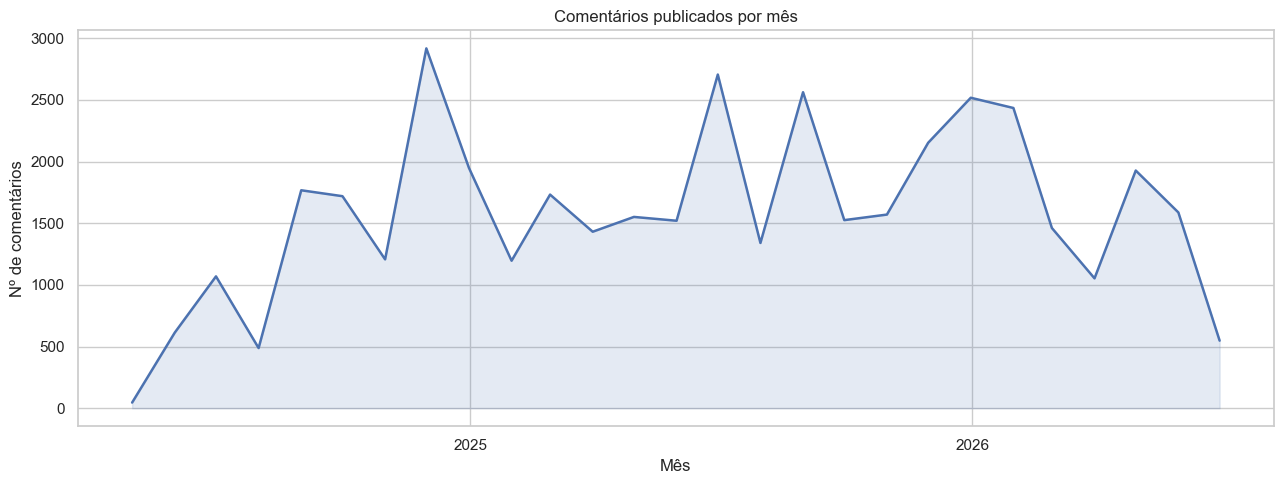

In [9]:
# Gráfico principal: comentários publicados por mês
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(monthly.index, monthly["n_comentarios"], color="#4C72B0", lw=1.8)
ax.fill_between(monthly.index, monthly["n_comentarios"], alpha=0.15, color="#4C72B0")
ax.set_title("Comentários publicados por mês")
ax.set_xlabel("Mês")
ax.set_ylabel("Nº de comentários")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.tight_layout()
plt.show()

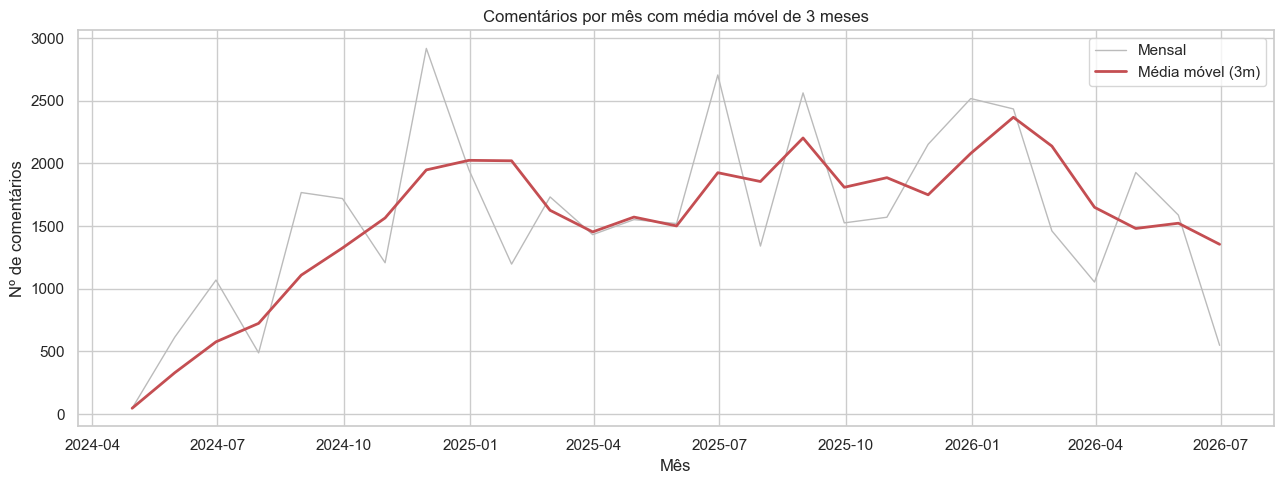

In [10]:
# Média móvel de 3 meses para suavizar a tendência
monthly["mm3"] = monthly["n_comentarios"].rolling(3, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(monthly.index, monthly["n_comentarios"], color="#bbbbbb", lw=1, label="Mensal")
ax.plot(monthly.index, monthly["mm3"], color="#C44E52", lw=2, label="Média móvel (3m)")
ax.set_title("Comentários por mês com média móvel de 3 meses")
ax.set_xlabel("Mês")
ax.set_ylabel("Nº de comentários")
ax.legend()
fig.tight_layout()
plt.show()

## 5. Comentários originais vs respostas ao longo do tempo

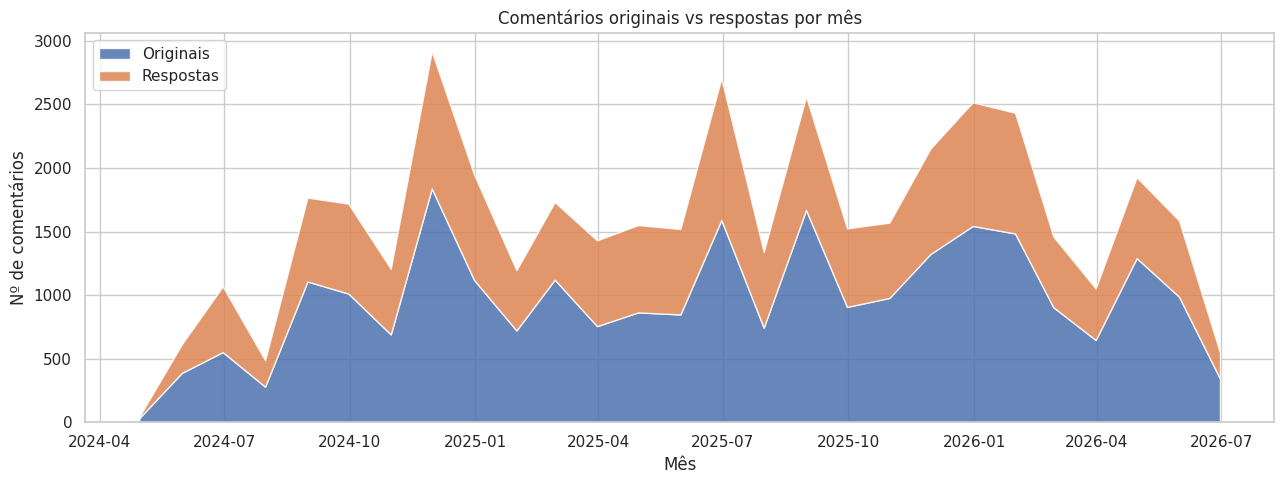

In [8]:
by_type = (
    df.set_index("published_at")
      .groupby([pd.Grouper(freq="ME"), "is_reply"])
      .size()
      .unstack(fill_value=0)
      .rename(columns={False: "originais", True: "respostas"})
)

fig, ax = plt.subplots(figsize=(13, 5))
ax.stackplot(
    by_type.index,
    by_type.get("originais", 0),
    by_type.get("respostas", 0),
    labels=["Originais", "Respostas"],
    colors=["#4C72B0", "#DD8452"],
    alpha=0.85,
)
ax.set_title("Comentários originais vs respostas por mês")
ax.set_xlabel("Mês")
ax.set_ylabel("Nº de comentários")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

## 6. Sazonalidade: volume por mês do ano e por dia da semana

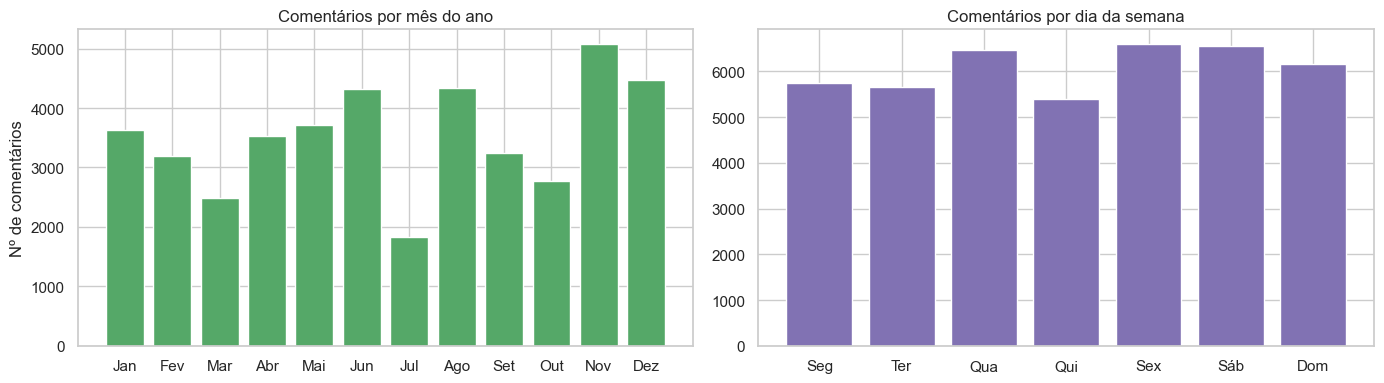

In [11]:
df["mes"] = df["published_at"].dt.month
df["dow"] = df["published_at"].dt.dayofweek  # 0 = segunda

meses_pt = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun", "Jul", "Ago", "Set", "Out", "Nov", "Dez"]
dias_pt = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

m = df.groupby("mes").size().reindex(range(1, 13), fill_value=0)
axes[0].bar(meses_pt, m.values, color="#55A868")
axes[0].set_title("Comentários por mês do ano")
axes[0].set_ylabel("Nº de comentários")

d = df.groupby("dow").size().reindex(range(7), fill_value=0)
axes[1].bar(dias_pt, d.values, color="#8172B3")
axes[1].set_title("Comentários por dia da semana")

fig.tight_layout()
plt.show()

## 7. Comentaristas mais ativos e comentários mais curtidos

In [12]:
top_autores = (
    df.groupby(["author", "author_channel_id"])
      .agg(n_comentarios=("comment_id", "count"), likes_totais=("like_count", "sum"))
      .sort_values("n_comentarios", ascending=False)
      .head(20)
)
top_autores

,,n_comentarios,likes_totais
author,author_channel_id,,
@MotoristaSincero10,UC-BdGoOqh8Zkpy3fkIKg7hA,439,609
@CanalGTAutos,UCT2J6PZM2W1Zl2kcBcFEe9A,398,270
@L1PEX,UCpRAM8vmxUYQcV2Dku7y8Eg,206,33
@jeandealmeida9927,UCBbAwqU9EcOoUqIO34nPOTw,162,102
@CanaldoBlogdoCadeirante,UCCiXI5slI_gC5PY-BaLza7A,129,122
@LucasAbriata,UCOypnH-5DDOh1WXHJxm_t1A,124,1641
@PatriciaAlbani,UCBtSp6oNEiZeNyIWL15JWzg,122,42
@mycarsbr,UCLFbmb6wLvCH42tVggh0KAA,102,154
@sergiofeo686,UCRMJTr_B58xmF7M5JzUi2Ig,88,40


In [13]:
cols = ["author", "like_count", "comment"]
top_likes = df.sort_values("like_count", ascending=False)[cols].head(20).copy()
top_likes["comment"] = top_likes["comment"]
top_likes

,author,like_count,comment
31923,@caio5250,1811,"Entrega o básico, brasileiro que se acostumou ..."
7573,@felipepc8868,1608,Cheguei mais rápido do que a Volkswagen no ouv...
15082,@Iucasoliveirasx,1407,Como fazer 300 pila por diaa!↙️🔥
37709,@jotasiq,1326,Não tem ACC\nNão tem 6 airbags\nNão tem freio ...
32496,@gustavocarneiros02,994,Peguei um desse essa semana e estou 100% satis...
42315,@PabloPérez-o7u4b,944,"Poner a un Youtuber en una ""lista negra"" solo ..."
1378,@rafaellopez2382,795,La cara de la concesionaria que le prestó el a...
35973,@marcosdias2454,794,O cara mostrando um desempenho absurdo de um m...
12632,@thor_nardo,758,"Se tem Lucão com uniforme de round 6, tem like!"
4571,@HobbiesDaVida,689,Comprei esse carro por 119.990 com o pacote sm...


## 8. Distribuição do tamanho dos comentários

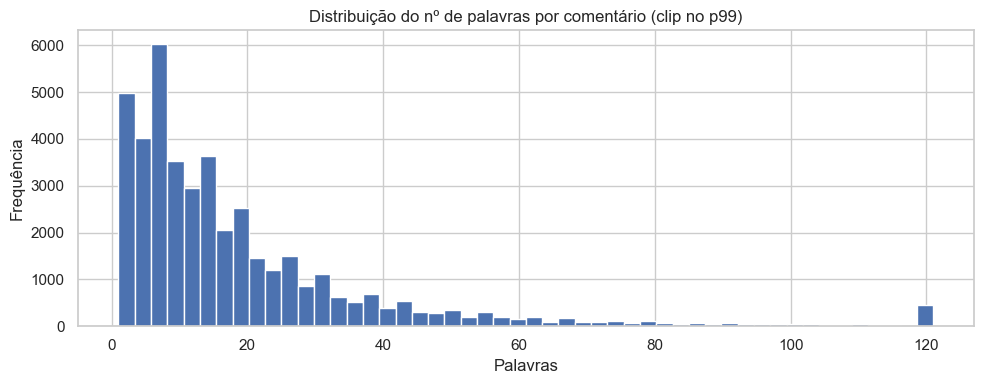

In [14]:
fig, ax = plt.subplots(figsize=(10, 4))
data = df["comment_words"].clip(upper=df["comment_words"].quantile(0.99))
ax.hist(data, bins=50, color="#4C72B0", edgecolor="white")
ax.set_title("Distribuição do nº de palavras por comentário (clip no p99)")
ax.set_xlabel("Palavras")
ax.set_ylabel("Frequência")
fig.tight_layout()
plt.show()

## 9. Co-ocorrência: palavras que mais aparecem junto a um termo de interesse

Aqui analisamos quais palavras mais ocorrem **próximas** de um termo de interesse
(ex.: `freio`, `motor`). Em vez de exigir adjacência exata, usamos uma **janela de contexto**:
para cada ocorrência do termo, contamos as palavras que aparecem até `janela` posições
antes ou depois. Isso captura colocações de forma mais robusta em linguagem natural.

Também geramos **bigramas** e **trigramas** que contêm o termo, para ver as combinações
literais mais frequentes.

In [15]:
# --- Pré-processamento de texto para análise de co-ocorrência ---
import re
from collections import Counter

# Lista de stopwords em português (palavras muito comuns, sem valor analítico).
STOPWORDS = {
    "a", "o", "e", "é", "de", "do", "da", "dos", "das", "em", "no", "na", "nos", "nas",
    "um", "uma", "uns", "umas", "para", "pra", "por", "com", "sem", "que", "se", "ao", "aos",
    "à", "às", "como", "mas", "ou", "também", "já", "não", "sim", "mais", "menos", "muito",
    "muita", "muitos", "muitas", "isso", "isto", "aquilo", "este", "esta", "esse", "essa",
    "aquele", "aquela", "eu", "tu", "ele", "ela", "nós", "vós", "eles", "elas", "me", "te",
    "lhe", "nos", "vos", "meu", "minha", "seu", "sua", "dele", "dela", "foi", "ser", "estar",
    "tem", "ter", "vai", "vou", "está", "são", "era", " years", "the", "of", "to", "and",
    "só", "lá", "aqui", "ai", "aí", "então", "porque", "pois", "quando", "onde", "qual",
    "quem", "todo", "toda", "todos", "todas", "cada", "outro", "outra", "bem", "vc", "voce",
    "você", "tá", "ta", "né", "pq", "q", "n", "dá", "faz", "fica", "ficou", "vez", "agora",
    "os", "as", "carros", "carro", "fiat", "fastback"
}

TOKEN_RE = re.compile(r"[a-zà-ú]+", re.IGNORECASE)

def tokenizar(texto):
    """Minúsculas, mantém apenas letras (inclui acentos), remove stopwords e tokens de 1 letra."""
    tokens = TOKEN_RE.findall(str(texto).lower())
    return [t for t in tokens if t not in STOPWORDS and len(t) > 1]

# Aplica a tokenização uma única vez e guarda no dataframe para reutilizar.
df["tokens"] = df["comment"].apply(tokenizar)
print("Exemplo de tokens do primeiro comentário:")
print(df["tokens"].iloc[0][:20])
print("Comentário original:")
print(df["comment"].iloc[0])

Exemplo de tokens do primeiro comentário:
['comenta', 'cidade', 'estado']
Comentário original:
Comenta aqui a sua cidade e seu estado 👇🏻👇🏻👇🏻


In [16]:
# --- Função de co-ocorrência por janela de contexto ---
def coocorrencias(termo, janela=4, top=20):
    """
    Conta palavras que aparecem dentro de `janela` posições (antes/depois)
    de `termo` em todos os comentários. Retorna um DataFrame ordenado.
    """
    termo = termo.lower()
    contador = Counter()
    n_ocorrencias = 0

    for tokens in df["tokens"]:
        idxs = [i for i, t in enumerate(tokens) if t == termo]
        n_ocorrencias += len(idxs)
        for i in idxs:
            ini = max(0, i - janela)
            fim = min(len(tokens), i + janela + 1)
            for j in range(ini, fim):
                if j != i:
                    contador[tokens[j]] += 1

    res = (
        pd.DataFrame(contador.most_common(top), columns=["palavra", "frequencia"])
        if contador else pd.DataFrame(columns=["palavra", "frequencia"])
    )
    print(f"Termo '{termo}': {n_ocorrencias} ocorrências em {len(df)} comentários.")
    return res

def ngramas_com_termo(termo, n=2, top=15):
    """
    Extrai os n-gramas (bigramas n=2, trigramas n=3) que CONTÊM o termo,
    mostrando as combinações literais mais frequentes.
    """
    termo = termo.lower()
    contador = Counter()
    for tokens in df["tokens"]:
        for i in range(len(tokens) - n + 1):
            grama = tokens[i:i + n]
            if termo in grama:
                contador[" ".join(grama)] += 1
    return (
        pd.DataFrame(contador.most_common(top), columns=[f"{n}-grama", "frequencia"])
        if contador else pd.DataFrame(columns=[f"{n}-grama", "frequencia"])
    )

# >>> Defina aqui sua palavra de interesse <<<
TERMO = "freio"

tabela_cooc = coocorrencias(TERMO, janela=4, top=20)
tabela_cooc

Termo 'freio': 1402 ocorrências em 42585 comentários.


,palavra,frequencia
0,disco,567
1,tambor,468
2,traseira,205
3,rodas,200
4,traseiro,122
5,mão,91
6,freio,90
7,eletrônico,88
8,mesmo,66
9,airbags,62


In [17]:
# Bigramas e trigramas que contêm o termo de interesse
print(f"=== Bigramas com '{TERMO}' ===")
display(ngramas_com_termo(TERMO, n=2, top=15))

print(f"=== Trigramas com '{TERMO}' ===")
display(ngramas_com_termo(TERMO, n=3, top=15))

=== Bigramas com 'freio' ===


,2-grama,frequencia
0,freio disco,492
1,freio tambor,376
2,freio mão,85
3,freio estacionamento,52
4,freio traseiro,44
5,esportivo freio,27
6,airbags freio,24
7,colocar freio,21
8,nem freio,20
9,disco freio,20


=== Trigramas com 'freio' ===


,3-grama,frequencia
0,freio disco rodas,128
1,freio disco traseira,81
2,freio tambor traseira,58
3,freio disco traseiro,47
4,freio estacionamento eletrônico,33
5,freio mão eletrônico,28
6,freio disco quatro,28
7,freio traseiro tambor,22
8,esportivo freio tambor,20
9,nem freio disco,18


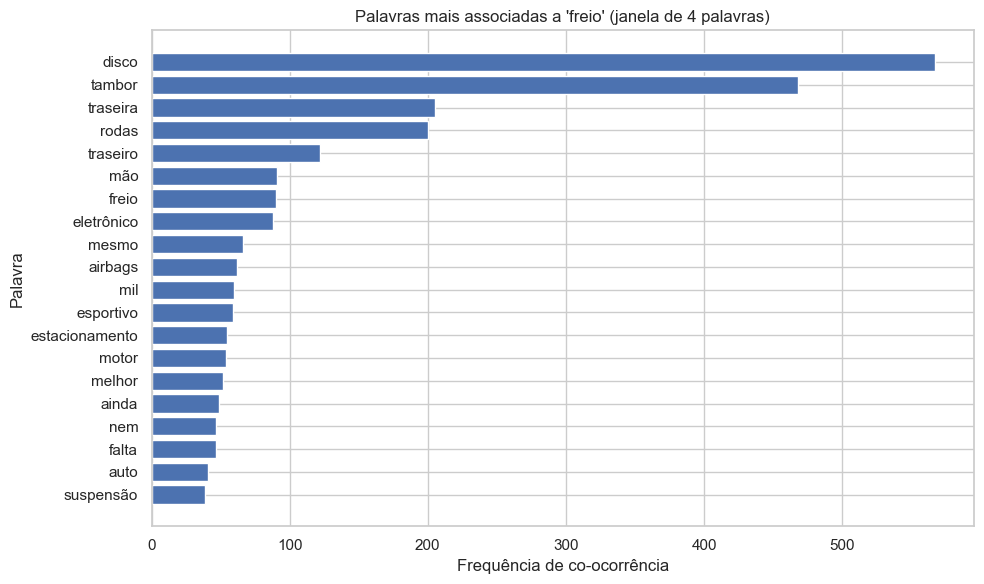

In [18]:
# Gráfico das palavras mais associadas ao termo de interesse
if not tabela_cooc.empty:
    fig, ax = plt.subplots(figsize=(10, 6))
    dados = tabela_cooc.iloc[::-1]  # inverte para a maior ficar no topo
    ax.barh(dados["palavra"], dados["frequencia"], color="#4C72B0")
    ax.set_title(f"Palavras mais associadas a '{TERMO}' (janela de 4 palavras)")
    ax.set_xlabel("Frequência de co-ocorrência")
    ax.set_ylabel("Palavra")
    fig.tight_layout()
    plt.show()
else:
    print(f"Nenhuma ocorrência de '{TERMO}' encontrada nos comentários.")

In [19]:
# Comparar vários termos de interesse de uma vez
TERMOS_INTERESSE = ["freio", "motor"]

for termo in TERMOS_INTERESSE:
    print(f"\n{'='*50}\nTop palavras associadas a '{termo}':\n{'='*50}")
    display(coocorrencias(termo, janela=4, top=10))


Top palavras associadas a 'freio':
Termo 'freio': 1402 ocorrências em 42585 comentários.


,palavra,frequencia
0,disco,567
1,tambor,468
2,traseira,205
3,rodas,200
4,traseiro,122
5,mão,91
6,freio,90
7,eletrônico,88
8,mesmo,66
9,airbags,62



Top palavras associadas a 'motor':
Termo 'motor': 2713 ocorrências em 42585 comentários.


,palavra,frequencia
0,turbo,273
1,mesmo,225
2,motor,218
3,el,184
4,elétrico,176
5,cilindros,165
6,km,110
7,bom,104
8,cv,102
9,barulho,99


## 10. Modelagem de tópicos com BERTopic

Até aqui contamos palavras e co-ocorrências. Agora damos um passo adiante: vamos
**descobrir automaticamente os assuntos** (tópicos) presentes nos comentários, sem
definir antecipadamente quais são. Para isso usamos o **BERTopic**, que combina quatro
ideias em sequência:

1. **Embeddings** — cada comentário vira um vetor numérico que captura seu *significado*.
   Usamos `paraphrase-multilingual-MiniLM-L12-v2`, um modelo treinado em vários idiomas
   (inclusive português), ideal para comentários em PT-BR.
2. **Redução de dimensionalidade (UMAP)** — os embeddings têm centenas de dimensões.
   O UMAP comprime para poucas dimensões preservando a vizinhança (quem é parecido
   continua perto), o que facilita o agrupamento.
3. **Clusterização (HDBSCAN)** — agrupa comentários parecidos em tópicos e, ao contrário
   do K-Means, **não exige definir o número de tópicos** e marca comentários atípicos
   como *ruído* (tópico `-1`).
4. **c-TF-IDF** — para cada cluster, identifica as palavras que melhor *caracterizam*
   aquele tópico em relação aos demais.

> **Por que isso importa em mídias sociais?** Comentários são curtos, informais e em
> grande volume. Ler tudo manualmente é inviável; o BERTopic resume milhares de
> comentários em um punhado de temas interpretáveis.

> **Obs**.: As células de instalação (!pip install) estão separadas e comentadas para rodar uma vez por sessão no Colab. Recomendo fortemente ativar GPU no Colab (Ambiente de execução → Alterar tipo de ambiente → GPU), já que tanto o BERTopic quanto o classificador de emoções ficam bem mais rápidos — o código detecta a GPU automaticamente.

### 10.1. Instalação das bibliotecas

Execute apenas uma vez por sessão do Colab. A instalação pode levar alguns minutos.

In [20]:
# Instala BERTopic e dependências (descomente para rodar no Colab)
# O BERTopic já traz UMAP, HDBSCAN e sentence-transformers como dependências.
!pip install -q bertopic sentence-transformers

# Reinicie o ambiente de execução se o Colab pedir, depois siga para a próxima célula.

### 10.2. Preparação dos documentos

Cada comentário é um "documento". Fazemos uma limpeza leve e removemos comentários
vazios ou curtíssimos, que não trazem informação de tópico e atrapalham a clusterização.

In [21]:
# Monta a lista de documentos a partir da coluna de comentários
docs_raw = df["comment"].astype(str)

# Limpeza leve: remove URLs e espaços extras (mantém o texto legível para o modelo)
import re
def limpar_leve(texto):
    texto = re.sub(r"http\S+|www\.\S+", " ", texto)   # remove links
    texto = re.sub(r"\s+", " ", texto).strip()          # normaliza espaços
    return texto

docs_series = docs_raw.apply(limpar_leve)

# Mantém apenas comentários com um mínimo de conteúdo (>= 4 palavras)
mask_validos = docs_series.str.split().apply(len) >= 4
docs = docs_series[mask_validos].tolist()
docs_index = df.index[mask_validos]   # guardamos o índice para juntar os tópicos ao df depois

print(f"Total de comentários: {len(df)}")
print(f"Documentos válidos para modelagem: {len(docs)}")
print("\nExemplo:")
print(docs[0][:200])

Total de comentários: 42585
Documentos válidos para modelagem: 37602

Exemplo:
Comenta aqui a sua cidade e seu estado 👇🏻👇🏻👇🏻


### 10.3. Montando o pipeline do BERTopic

Aqui está o coração da técnica. Construímos cada componente explicitamente — assim
fica didático e você controla cada etapa, em vez de usar os padrões "escondidos" do
BERTopic.

Parâmetros importantes para ajustar:
- `n_neighbors` (UMAP): valores maiores → estrutura mais global; menores → mais local.
- `min_cluster_size` (HDBSCAN): tamanho mínimo de um tópico. **É o parâmetro que mais
  muda o resultado**: aumente para ter poucos tópicos grandes, diminua para muitos
  tópicos específicos.
- `random_state` no UMAP torna o resultado **reproduzível** (o UMAP é estocástico).

In [23]:
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from bertopic import BERTopic

# 1) EMBEDDINGS — modelo multilíngue (funciona bem em português)
embedding_model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

# 2) REDUÇÃO DE DIMENSIONALIDADE — UMAP
#    random_state fixa a aleatoriedade para resultados reproduzíveis.
umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42,
)

# 3) CLUSTERIZAÇÃO — HDBSCAN
#    prediction_data=True é necessário ao usar HDBSCAN customizado dentro do BERTopic.
hdbscan_model = HDBSCAN(
    min_cluster_size=15,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True,
)

# 4) VETORIZADOR para o c-TF-IDF — remove stopwords em português ao descrever os tópicos.
#    Reaproveitamos a lista STOPWORDS criada na Seção 9 (se não existir, usa lista vazia).
try:
    stopwords_pt = list(STOPWORDS)
except NameError:
    stopwords_pt = None

vectorizer_model = CountVectorizer(stop_words=stopwords_pt, ngram_range=(1, 2))

# Monta o BERTopic juntando todas as peças
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    language="multilingual",
    calculate_probabilities=True,
    verbose=True,
)

print("Pipeline do BERTopic montado com sucesso.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Pipeline do BERTopic montado com sucesso.


### 10.4. Treinando o modelo

O método `fit_transform` executa as quatro etapas de uma vez e retorna, para cada
documento, o **tópico atribuído** e a **probabilidade**. Em CPU pode levar alguns
minutos; com GPU (no Colab: *Ambiente de execução → Alterar tipo → GPU*) é bem mais rápido.

In [24]:
# Treina o modelo e atribui um tópico a cada documento
topics, probs = topic_model.fit_transform(docs)

# Tabela-resumo dos tópicos encontrados.
# O tópico -1 agrupa os "outliers" (comentários que não se encaixam em nenhum tema).
info = topic_model.get_topic_info()
print(f"Número de tópicos encontrados (excluindo ruído): {len(info[info.Topic != -1])}")
info.head(15)

2026-06-17 20:57:16,670 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/1176 [00:00<?, ?it/s]

2026-06-17 21:07:00,888 - BERTopic - Embedding - Completed ✓
2026-06-17 21:07:00,890 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-17 21:08:35,659 - BERTopic - Dimensionality - Completed ✓
2026-06-17 21:08:35,663 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-17 21:10:08,386 - BERTopic - Cluster - Completed ✓
2026-06-17 21:10:08,397 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-17 21:10:12,057 - BERTopic - Representation - Completed ✓


Número de tópicos encontrados (excluindo ruído): 201


,Topic,Count,Name,Representation,Representative_Docs
0,-1,16705,-1_motor_el_la_un,"[motor, el, la, un, es, mesmo, en, tenho, preç...","[No se la calidad de fiat, pero ese motor es m..."
1,0,1460,0_tiggo_melhor_abarth_2008,"[tiggo, melhor, abarth, 2008, t200, estou, fas...","[Em comparação aos concorrentes diretos, fastb..."
2,1,1049,1_vídeo_video_vídeos_parabéns,"[vídeo, video, vídeos, parabéns, videos, youtu...","[Muito bom esse vídeo, Muito bom esse vídeo, M..."
3,2,927,2_kkkkk_kkkk_kkkkkk_kkk,"[kkkkk, kkkk, kkkkkk, kkk, kkkkkkk, kkkkkkkk, ...","[Kkkkkk ou seja uma merda kkkkkkkk, Bonito ele..."
4,3,925,3_gasolina_cidade_km_etanol,"[gasolina, cidade, km, etanol, estrada, média,...",[Na cidade o meu fastback t200 faz 9 km/l com ...
5,4,718,4_los_un_en_el,"[los, un, en, el, con, sempre, segmento, es, p...","[No se lo dijeron por ahí, pero a tu pregunta ..."
6,5,708,5_amigo_obrigado_matiasanticotv_obrigado pela,"[amigo, obrigado, matiasanticotv, obrigado pel...",[@willermeireles5722 Valeu e muito obrigado pe...
7,6,701,6_brasil_brasileiro_brasileiros_compra,"[brasil, brasileiro, brasileiros, compra, paga...","[Brasileiro gosta de ser enganado😂😂😂😂, A fiat ..."
8,7,444,7_mil_00_000_100,"[mil, 00, 000, 100, 990, audace, 119, reais, l...",[Caramba 👏🏻👏🏻 vc é de onde? Aqui em BH achei d...
9,8,407,8_basalt_citroen_citroen basalt_basalt dark,"[basalt, citroen, citroen basalt, basalt dark,...","[O Basalt é mais bonito., Citroen Basalt é bem..."


### 10.5. Inspecionando o conteúdo dos tópicos

Para cada tópico, o c-TF-IDF lista as palavras mais características. É assim que
*interpretamos* e damos nome a cada tema.

In [25]:
# Mostra as palavras-chave dos primeiros tópicos (ignorando o ruído -1)
topicos_validos = [t for t in info.Topic.tolist() if t != -1]

for t in topicos_validos[:5]:
    palavras = topic_model.get_topic(t)        # lista de (palavra, peso)
    termos = ", ".join(p for p, _ in palavras[:8])
    print(f"Tópico {t}: {termos}")
    print("-" * 60)

Tópico 0: tiggo, melhor, abarth, 2008, t200, estou, fast, pelo
------------------------------------------------------------
Tópico 1: vídeo, video, vídeos, parabéns, videos, youtube, canal, pelo vídeo
------------------------------------------------------------
Tópico 2: kkkkk, kkkk, kkkkkk, kkk, kkkkkkk, kkkkkkkk, kkkkkkkkk, kkkkkkkkkk
------------------------------------------------------------
Tópico 3: gasolina, cidade, km, etanol, estrada, média, fazendo, consumo
------------------------------------------------------------
Tópico 4: los, un, en, el, con, sempre, segmento, es
------------------------------------------------------------


In [26]:
# Liga o tópico de volta ao dataframe original, para análises cruzadas
df["topico"] = -2  # -2 = não usado na modelagem (comentário curto demais)
df.loc[docs_index, "topico"] = topics

# Quantos comentários por tópico?
df["topico"].value_counts().sort_index()

topico
-2       4983
-1      16705
 0       1460
 1       1049
 2        927
        ...  
 196       16
 197       15
 198       15
 199       15
 200       15
Name: count, Length: 203, dtype: int64

### 10.6. Visualizações interativas

O BERTopic gera gráficos interativos (Plotly) muito úteis para apresentar em aula.
Execute cada um e explore passando o mouse sobre os elementos.

> Dica didática: o *mapa de distância entre tópicos* mostra quais temas são
> semanticamente próximos; o *barchart* mostra as palavras de cada tópico.

In [27]:
# Mapa de distância entre tópicos (cada bolha é um tópico; proximidade = similaridade)
topic_model.visualize_topics()

In [28]:
# Palavras mais relevantes por tópico (barras)

topic_model.visualize_barchart(top_n_topics=8)

In [29]:
# Heatmap de similaridade entre tópicos
topic_model.visualize_heatmap(top_n_topics=20)

### 10.7. (Opcional) Tópicos ao longo do tempo

Como já temos `published_at`, podemos ver **como os temas evoluem mês a mês** —
extremamente útil para entender narrativas em mídias sociais.

In [35]:
# Tópicos ao longo do tempo (usa as datas dos documentos válidos)
timestamps = df.loc[docs_index, "published_at"].tolist()

topics_over_time = topic_model.topics_over_time(
    docs,
    timestamps,
    nr_bins=20,   # agrupa em ~20 intervalos de tempo
)

topicos_escolhidos = [1, 7, 8, 9]
topic_model.visualize_topics_over_time(topics_over_time, topics=topicos_escolhidos)

20it [01:55,  5.79s/it]


## 11. Detecção de emoções nos comentários

Tópicos dizem *sobre o que* as pessoas falam. **Emoções** dizem *como elas se sentem*
ao falar. Vamos classificar cada comentário usando o modelo
`tabularisai/multilingual-emotion-classification`, que reconhece **11 emoções** em
23 idiomas (incluindo português):

> anger (raiva), contempt (desprezo), disgust (nojo), fear (medo), frustration
> (frustração), gratitude (gratidão), joy (alegria), love (amor), neutral (neutro),
> sadness (tristeza), surprise (surpresa).

Pontos importantes deste modelo:
- É **multi-rótulo**: um mesmo comentário pode ter **zero, uma ou várias** emoções.
- Usa `function_to_apply="sigmoid"` — cada emoção recebe uma probabilidade independente
  entre 0 e 1.
- O limiar padrão é **0,5**: acima disso, consideramos a emoção presente.

> **Cuidado metodológico (importante para a aula):** emoções são *culturalmente
> situadas*. As previsões são **sinais probabilísticos**, não a verdade sobre o que a
> pessoa realmente sentia. Trate os resultados como tendências agregadas, não como
> diagnóstico individual.

In [28]:
# Instala a biblioteca transformers (descomente para rodar no Colab)
!pip install -q transformers

### 11.1. Carregando o classificador de emoções

`top_k=None` faz o modelo retornar a pontuação de **todas** as emoções (não só a mais
provável), o que é essencial num cenário multi-rótulo.

In [29]:
from transformers import pipeline
import torch

# Usa GPU se disponível (device=0), senão CPU (device=-1)
device = 0 if torch.cuda.is_available() else -1
print("Usando", "GPU" if device == 0 else "CPU")

emotion_classifier = pipeline(
    "text-classification",
    model="tabularisai/multilingual-emotion-classification",
    function_to_apply="sigmoid",  # multi-rótulo: probabilidade independente por emoção
    top_k=None,                   # retorna todas as 11 emoções
    device=device,
)

# Teste rápido
exemplo = emotion_classifier("Adorei esse vídeo, ficou incrível!")
for e in sorted(exemplo[0], key=lambda x: x["score"], reverse=True)[:3]:
    nome = e["label"]
    score = e["score"]
    print(f"{nome:>12}: {score:.3f}")

Usando GPU


config.json:   0%|          | 0.00/1.26k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/314 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

         joy: 0.901
     neutral: 0.256
        love: 0.030


### 11.2. Classificando todos os comentários

Processamos em **lotes** (batches) para ganhar velocidade. Para cada comentário
guardamos a emoção dominante (maior pontuação) e o dicionário completo de pontuações,
caso queira análises multi-rótulo depois.

> Em datasets grandes isso pode demorar. Para testar em aula, reduza com
> `df_amostra = df.sample(500)` antes de rodar.

In [30]:
# Para acelerar a aula, você pode trabalhar com uma amostra:
# trabalhar_com = df.sample(500, random_state=42).copy()
trabalhar_com = df   # ou use o dataframe inteiro

textos = trabalhar_com["comment"].astype(str).str.slice(0, 512).tolist()  # trunca em 512 chars

# Classifica em lotes
resultados = emotion_classifier(textos, batch_size=32, truncation=True)

# Para cada comentário, extrai a emoção dominante e o score
emocao_dominante = []
score_dominante = []
todas_emocoes = []

for r in resultados:
    # r é uma lista de {label, score} (uma por emoção)
    melhor = max(r, key=lambda x: x["score"])
    emocao_dominante.append(melhor["label"])
    score_dominante.append(melhor["score"])
    todas_emocoes.append({e["label"]: e["score"] for e in r})

trabalhar_com = trabalhar_com.copy()
trabalhar_com["emocao"] = emocao_dominante
trabalhar_com["emocao_score"] = score_dominante

print("Classificação concluída.")
trabalhar_com[["comment", "emocao", "emocao_score"]].head(10)

Classificação concluída.


,comment,emocao,emocao_score
0,Comenta aqui a sua cidade e seu estado 👇🏻👇🏻👇🏻,neutral,0.990315
1,Esse torque. Essa aceleracao.\n9 por litros.\n...,neutral,0.938070
2,Pensei em colocar uma série de argumentos aqui...,neutral,0.693491
3,​@CanalGTAutos😂😂😂😂😂😂.\nUma serie de argumento ...,contempt,0.561666
4,​@CovardeCovarde-u8k5nQualquer coisa vai avisa...,neutral,0.864263
5,SUV ?,contempt,0.473131
6,Tá fazendo mais que meu tera 1.0tsi,neutral,0.533973
7,Compacto com porta-malas maior de 500 l?,neutral,0.991645
8,Sim. Tamanho de porta-malas não muda a categor...,neutral,0.989509
9,"O Meu By Barth que é o mesmo motor,andando de ...",neutral,0.991742


### 11.3. Distribuição geral das emoções

A pergunta mais direta: **qual o clima emocional** dos comentários?

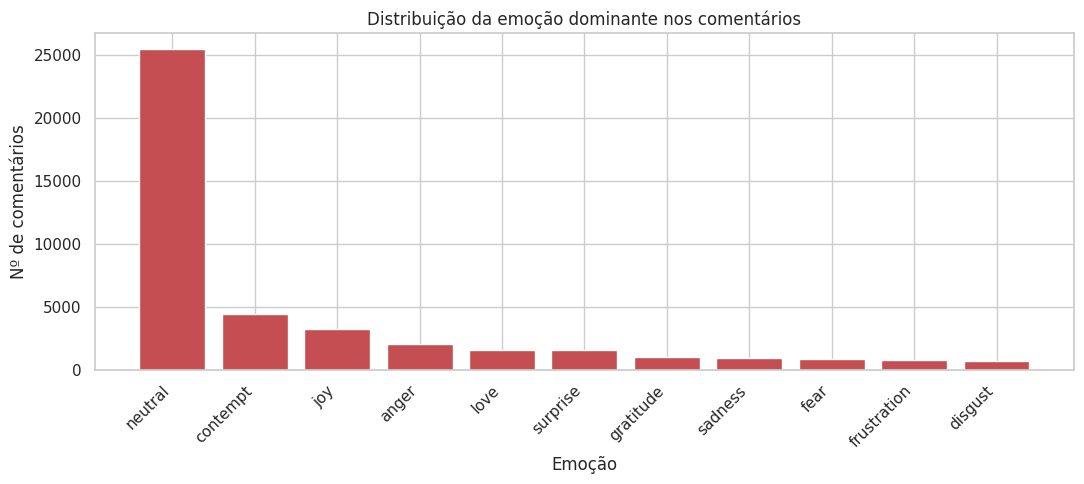

,count
emocao,
neutral,59.8
contempt,10.3
joy,7.6
anger,4.8
love,3.7
surprise,3.7
gratitude,2.4
sadness,2.2
fear,2.0


In [31]:
# Contagem da emoção dominante por comentário
contagem_emocoes = trabalhar_com["emocao"].value_counts()

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(contagem_emocoes.index, contagem_emocoes.values, color="#C44E52")
ax.set_title("Distribuição da emoção dominante nos comentários")
ax.set_xlabel("Emoção")
ax.set_ylabel("Nº de comentários")
plt.xticks(rotation=45, ha="right")
fig.tight_layout()
plt.show()

# Tabela em porcentagem
(contagem_emocoes / contagem_emocoes.sum() * 100).round(1)

### 11.4. Emoções ao longo do tempo

Cruzando com `published_at`, vemos como o sentimento da audiência **evolui mês a mês** —
um pico de raiva ou frustração pode coincidir com um evento específico.

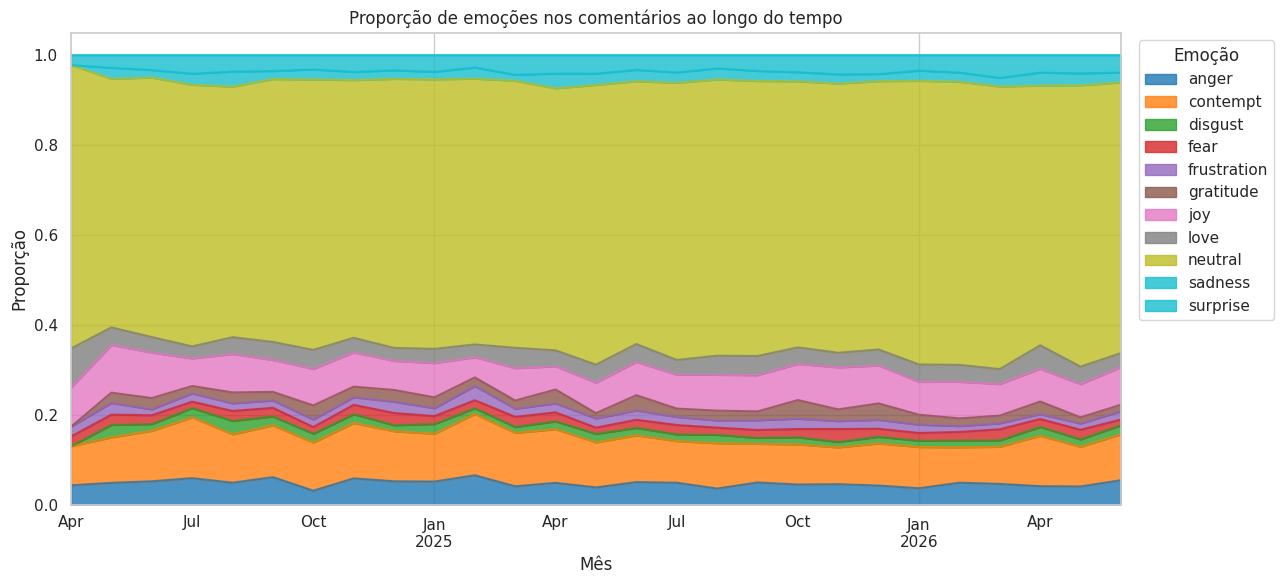

In [32]:
# Série mensal da proporção de cada emoção
emo_tempo = (
    trabalhar_com
    .dropna(subset=["published_at"])
    .set_index("published_at")
    .groupby([pd.Grouper(freq="ME"), "emocao"])
    .size()
    .unstack(fill_value=0)
)

# Converte para proporção (cada mês soma 100%)
emo_prop = emo_tempo.div(emo_tempo.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(13, 6))
emo_prop.plot.area(ax=ax, alpha=0.8, colormap="tab10")
ax.set_title("Proporção de emoções nos comentários ao longo do tempo")
ax.set_xlabel("Mês")
ax.set_ylabel("Proporção")
ax.legend(title="Emoção", bbox_to_anchor=(1.01, 1), loc="upper left")
fig.tight_layout()
plt.show()

### 11.5. Cruzando emoção com tópico

A síntese das duas seções: **qual a emoção predominante em cada tópico?** Isso revela,
por exemplo, se o tópico sobre "freio" carrega mais frustração, ou se o tópico sobre
um produto carrega mais gratidão.

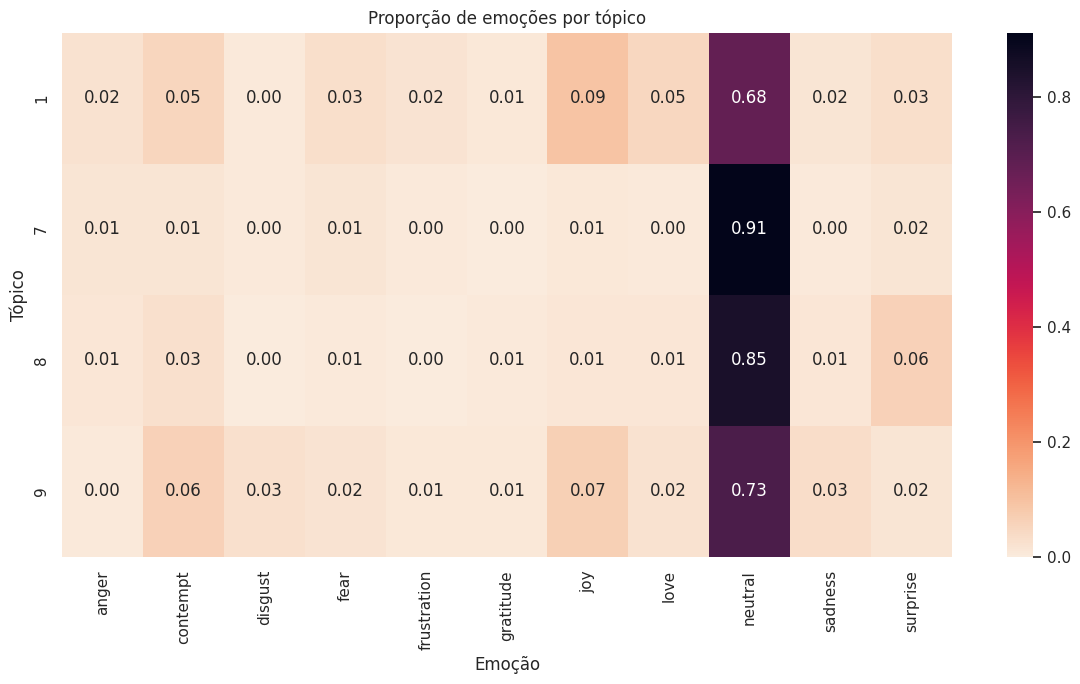

In [37]:
# Só faz sentido se a Seção 10 (BERTopic) já foi executada
# Escolha os tópicos que quer no heatmap pelo número (veja os IDs em topic_model.get_topic_info())
topicos_escolhidos = [1, 7, 8, 9]

if "topico" in trabalhar_com.columns or "topico" in df.columns:
    # Garante que temos a coluna de tópico no mesmo dataframe
    base = trabalhar_com.copy()
    if "topico" not in base.columns:
        base = base.join(df["topico"])

    # Tabela cruzada tópico x emoção (proporção por tópico), apenas para os tópicos escolhidos
    cruzado = (
        base[base["topico"].isin(topicos_escolhidos)]
        .groupby(["topico", "emocao"])
        .size()
        .unstack(fill_value=0)
    )
    cruzado_prop = cruzado.div(cruzado.sum(axis=1), axis=0)

    fig, ax = plt.subplots(figsize=(12, 7))
    sns.heatmap(cruzado_prop, annot=True, fmt=".2f", cmap="rocket_r", ax=ax)
    ax.set_title("Proporção de emoções por tópico")
    ax.set_xlabel("Emoção")
    ax.set_ylabel("Tópico")
    fig.tight_layout()
    plt.show()
else:
    print("Execute a Seção 10 (BERTopic) antes para ter a coluna 'topico'.")

### 11.6. Síntese

Nesta parte do material vimos o fluxo completo de **manipulação de texto de mídias
sociais**:

| Etapa | Técnica | O que responde |
|-------|---------|----------------|
| Frequência e co-ocorrência | Contagem, n-gramas, janela de contexto | Quais palavras aparecem e com o quê |
| Modelagem de tópicos | BERTopic (embeddings + UMAP + HDBSCAN + c-TF-IDF) | Sobre **o que** se fala |
| Detecção de emoções | Classificador multilíngue multi-rótulo | **Como** as pessoas se sentem |

**Limitações:**
- Modelos treinados em dados sintéticos ou de outros domínios podem errar em gírias,
  ironia e sarcasmo — muito comuns em comentários.
- Tópicos e emoções são *interpretações estatísticas*, não verdades absolutas.
- Sempre valide uma amostra manualmente antes de tirar conclusões.

## Notas metodológicas

- A série mensal pode estar truncada nas bordas: o **primeiro e o último mês** costumam ser parciais (coleta começou/terminou no meio do mês). Considere descartá-los antes de interpretar tendências.
- Um pico de comentários não significa necessariamente mais atividade orgânica — pode refletir um vídeo viral pontual. Cruze com `dfvideos` para contextualizar.
- `published_at` está em UTC. Para análise de sazonalidade por hora/dia local, converta para o fuso do público-alvo.
